<a href="https://colab.research.google.com/github/gtzan/mir_book/blob/master/ch1_sinusoidworld/Explaining_the_DFT_a_music_perspective_part9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A music and sound exposition of the Discrete Fourier Transform (Part 9)
## Hilbert spaces, windowing, and zero-padding

In Parts 7 and Parts 8 we completed the overview of the notation used in the Discrete Fourier Transform by looking into the geometric interpretation of complex numbers and using phasors to represent sinusoidal signals and their combinations.

In this last part of the exposition we discuss the idea of Hilbert spaces in which we think of signals as linear-combination of the basis functions in an analogous way to how we think of vectors as linear combinations of the unit vectors for each coordinate axis. The dot-product can be thought of as a projection operator. Thinking about coordinate systems as a projection operator with an orthogonal basis will help us abstract different but related time-frequency mathematical transforms: the Fourier Series, the Discrete Fourier Transform, the z-transform, and the continuous Fourier Transform.
After this more mathematical discussion we also examine some important topics related to usage of the DFT in audio and music processing and understanding it's limitations.

# Hilbert Spaces

We have seen several situations so far where thinking of signals as phasors is helpful in understanding what is going on. It turns out that any periodic signal can be expressed as a sum of **sinusoids** or equivalently, **phasors**.
When a signal is represented as such as sum, we call this a **frequency domain** representation of the signal (when we process short chunks of signal at a time then we get a **time-frequency** representation. When studying signal processing there are 4 commonly used variants of frequency domain representations: the Fourier Series, the Discrete Fourier Transform, the z-transform, and the classical continuous Fourier Transform. We have already explored in some detail the DFT. The intuition behind all four of these representation is similar so we will explore this a bit further and point to resources for further learning in the **Part 10**.

Let's think of a geometric picture of a vector $v$ in standard three-dimensional cartesian space. This will help us generalize the basic ideas of a coordinate system to more general domains of applications and help us gain intuition about transformations from the time domain to the frequency domain.

In [1]:
import librosa
import IPython.display as ipd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import logging

# Silence the font manager logging system
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# xkcd style plots and suppress font warnings
plt.xkcd()

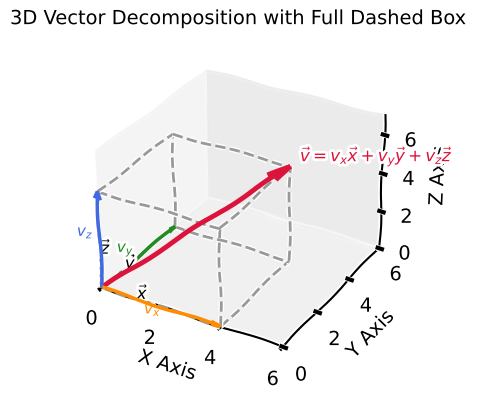

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Create 3D figure
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111, projection='3d')

# Define vector coordinates
v = np.array([4.0, 4.0, 5.0])
x, y, z = v

# 1. Plot the main vector v from origin (prominent and bold)
ax.quiver(0, 0, 0, x, y, z, color='crimson', linewidth=3.5, arrow_length_ratio=0.1, label=r'$\vec{v}$')

# 2. Plot the 3 component vectors along the axes representing v_x, v_y, v_z
ax.quiver(0, 0, 0, x, 0, 0, color='darkorange', linewidth=2.5, arrow_length_ratio=0.08)
ax.quiver(0, 0, 0, 0, y, 0, color='forestgreen', linewidth=2.5, arrow_length_ratio=0.08)
ax.quiver(0, 0, 0, 0, 0, z, color='royalblue', linewidth=2.5, arrow_length_ratio=0.08)

# 3. Plot full standard coordinate axes (faintly for reference)
ax.quiver(0, 0, 0, 1.0, 0, 0, color='gray', arrow_length_ratio=0.04, linestyle=':', alpha=0.4)
ax.quiver(0, 0, 0, 0, 1.0, 0, color='gray', arrow_length_ratio=0.04, linestyle=':', alpha=0.4)
ax.quiver(0, 0, 0, 0, 0, 1.5, color='gray', arrow_length_ratio=0.04, linestyle=':', alpha=0.4)

# Axis labels with vector arrows (x, y, z)
ax.text(1.2, 0, 0, r'$\vec{x}$', fontsize=12, fontweight='bold')
ax.text(0, 1.2, 0, r'$\vec{y}$', fontsize=12, fontweight='bold')
ax.text(0, 0, 1.8, r'$\vec{z}$', fontsize=12, fontweight='bold')

# Component labels along axes
ax.text(x / 2, -0.4, 0, r'$v_x$', fontsize=11, color='darkorange', fontweight='bold', ha='center')
ax.text(-0.5, y / 2, 0, r'$v_y$', fontsize=11, color='forestgreen', fontweight='bold', ha='center')
ax.text(-0.5, 0, z / 2, r'$v_z$', fontsize=11, color='royalblue', fontweight='bold', ha='center')

# 4. Plot a full dashed box enclosing the vector
# --- Bottom face (z = 0) ---
ax.plot([0, x], [0, 0], [0, 0], 'k--', alpha=0.4)
ax.plot([0, 0], [0, y], [0, 0], 'k--', alpha=0.4)
ax.plot([x, x], [0, y], [0, 0], 'k--', alpha=0.4)
ax.plot([0, x], [y, y], [0, 0], 'k--', alpha=0.4)

# --- Vertical edges connecting bottom to top face ---
ax.plot([0, 0], [0, 0], [0, z], 'k--', alpha=0.4)
ax.plot([x, x], [0, 0], [0, z], 'k--', alpha=0.4)
ax.plot([0, 0], [y, y], [0, z], 'k--', alpha=0.4)
ax.plot([x, x], [y, y], [0, z], 'k--', alpha=0.4)

# --- Top face (z = z) ---
ax.plot([0, x], [0, 0], [z, z], 'k--', alpha=0.4)
ax.plot([0, 0], [0, y], [z, z], 'k--', alpha=0.4)
ax.plot([x, x], [0, y], [z, z], 'k--', alpha=0.4)
ax.plot([0, x], [y, y], [z, z], 'k--', alpha=0.4)

# Label the vector tip with vector notation
ax.text(x + 0.2, y + 0.2, z + 0.2, r'$\vec{v} = v_x\vec{x} + v_y\vec{y} + v_z\vec{z}$', fontsize=12, color='crimson', fontweight='bold')

# Set limits and labels
ax.set_xlim([0, 6])
ax.set_ylim([0, 6])
ax.set_zlim([0, 7])

ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.set_title('3D Vector Decomposition with Full Dashed Box', fontsize=14, pad=15)

plt.tight_layout()
plt.show()

The vector $\vec{v}$ is written as a combination of the three unit vectors in each of the three coordinate directions:

$$
\vec{v} = v_x \vec{x} + v_y \vec{y} + v_z \vec{z}
$$


This equation shows that any vector $\vec{v}$ can be obtained by adding three parts together, a vector in the $x$-direction of length $v_x$, a vector in the $y$-direction of length $v_y$, and a vector in the $z$-direction of length $v_z$. The three unit-legth vectors in the coordinate directions, $\vec{x}$, $\vec{y}$, and $\vec{z}$ are called a *basis* for the three-dimenstional space. The numbers $v_x$, $v_y$, and $v_z$ are called the **projections** of the vector $\vec{v}$ onto the respective basis elemements. We will notate the projection of one vector $\vec{v}$ onto another $\vec{w}$ as $\langle \vec{v}, \vec{w} \rangle$. So we can write:

$$
\begin{align}
v_x = \langle \vec{v}, \vec{x} \rangle \\
v_y = \langle \vec{v}, \vec{y} \rangle \\
v_z = \langle \vec{v}, \vec{z} \rangle \\
\end{align}
$$

Note that if $\vec{v}$ is at right angles (orthogonal) to the x-axis, then $v_x = \langle \vec{v}, \vec{x} \rangle = 0$. One can easily show that the basis vector are mutually **orthogonal** and therefore the form an **orthogonal basis**. When projecting any vector $\vec{v}$ onto any other vector $\vec{w}$ it can be shown that it is equivalent to the **inner product** of the two vectors:

$$
\langle \vec{v}, \vec{w} \rangle = v_x w_x + v_y w_y + v_z w_z
$$

**Complex number detail:** The inner product of a vector with itself, is the square of the length of the vector.
$$
\langle \vec{v}, \vec{v} \rangle = \langle v_x^2 + v_y^2 + v_z^2 \rangle
$$

If the vector has coordinate values that are complex number, we want this to still be true. In order to make this happen we have to change the definition of the inner product using complex conjugates. The complex conjugate $c^*$ of a complex number $c = a+bj$ is $c^{*} = a-bj$. The inner product in this case is and the inner product with itself is still the square of the length:

$$
\langle \vec{v}, \vec{w} \rangle = v_x w_x^* + v_y w_y^* + v_z w_z^*
$$

When we have a **projection operator** and an **orthogonal basis** we define an **orthogonal coordinate system**. We will see that we can think of transformations to the frequency domain in the same way. Each one of the four variants can be defined by specifying the corresponding **projection operator** and **orthogonal basis**. Let's quickly go over them.

## Fourier Series

In Fourier Series, we want to represent periodic signals that are functions of a continuous time variable $t$ with $t$ in the range $0 \leq t \leq T$. If we think of every value of $t$ as a coordinate we can generalize the inner-product to be an integral i.e a continuous sum over the range. Instead of expressing finite vectors in terms of other finite vectors we are expressing continuous periodic functions in terms of other continous periodic functions. The generalized inner product between periodic functions $f(t)$ and $g(t)$ is:
$$
\langle f, g \rangle = \frac{1}{T} \int_{0}^{T} f(t) g^{*}(t)dt
$$

We have defined the projection operator now we need to define the basis elements. It makes sense to look into phasors with period T:
$$
e^{jk\omega_0t}, \;\;\; k=\dots,-1,0,1,2,\dots
$$
As one would expect it can be shown that these phasors are **orthogonal** to each other. Also note that the basis is indexed by integers but the functions we are representing are continuous - there is some complex math about when this can happen which we will not cover. So any periodic function can be written in terms of the basis with complex coordinates $c_k$ as follows:
$$
f(t) = \sum_{k=-inf}^{inf} c_k e^{jk\omega_0t}
$$
How do we find the coordinates/Fourier coefficents $c_k$? We simply project $f(t)$ on the $k-th$ basis element:
$$
c_k = \langle f(t), e^{jk\omega_0t} \rangle = \frac{1}{T}\int_{0}^{T} f(f) e^{-j\omega_0t} dt
$$

The sequence of $c_k$ is called the **spectrum**. Note the chane of sign in the phasor exponent. When I was first learning DSP I always had trouble remembering when it should be positive and when it should be negative. Thinking about it in terms of the inner-product and the complex conjugate when dealing with complex numbers makes remembering this easier.



## Discrete Fourier Transform

We have already looked at the Discrete Fourier Transform so let's again define it by using a projection operation/inner product:
$$
\langle x, y \rangle = \sum_{n=0}^{N-1} x[n] y^*[n]
$$
and then a basis which is a set of $N$ phasors:
$$
e^{jtk2\pi/N} \;\;\; 0 \leq k \leq N-1   
$$
Again one can show that the basis elements are orthogonal. Now you can see why we used the term basis while initial when thinking of inner-products as mechanisms for amplitude estimation I used the term probe. Once we have the projection operator and the basis elements we have our transform.

$$
x[t] = \frac{1}{N} \sum_{k=0}^{N-1} X[k] e^{jtk2\pi/N}
$$
The spectrum is obtained by projection of $x[t]$ onto each $k$th basis element:
$$
X[k] = \langle x, e^{jtk2\pi/N} \rangle = \sum_{t=0}^{N-1} x[t] e^{-jtk2\pi/N}
$$
Again note the change of sign because of the complex conjugate.



## The z-transform and the continuous Fourier Transform

The z-transform considers the case in which the signal is digtal/discrete but extends indefinitely rather than being periodic. The continous Fourier Transform (or simply the Fourier Transform) considers the case the signal is continuous and extendes indefinitely in time. In this case both the time and frequency domain are continuous lines of infinite extent. We will not go into the details but in both cases we just need to define appropriately a **projection operator/inner product**  and an **orthogonal basis** and we have our transforms.

The mathematical concept of extending the familiar geometry of Euclidean space into infinite-dimensional settings through vector spaces equipped with inner products and basis elements is called a **Hilbert Space** and allows all sorts of interesting connections to be made between different domains.


# Windowing

A fundamental assumption of the Discrete Fourier Transform (DFT) is that the signal to be analyzed is periodic and that the period aligns with the number of samples analyzed. Another way of stating this is that the DFT works well for estimating the amplitude of a sinusoid/phasor if that input signal corresponds to one of the basis/probe frequencies. If that assumption does not hold then then signal to be analyzed will not contain an integer number of cycles and when repeated there will be a discontinuity that results in multiple frequencies having a non-zero amplitude - this is termed **spectral leakage**.
Ideally we would like to reduce **spectral leakage** as it can lead to misleading information about the frequencies present in the signal.

The typical way to achieve this is by using a **window** or **window function**. This is a signal that is multiplied with the segment of a signal prior to taking the DFT when doing short-time processing. Windows that fade in and out can reduce the discontinuities. At the same time tapered windows can have the effect of widening the main lobe width which corresponds to the frequency resolution of the transform. In the plots below first we see the effect of windowing to an input that matches exactly one of the frequency bins.
You can see that when using a rectangular window (just taking a segment) there is a single peak at the corresponding bin (the shape that you see is caused by the cubic interpolation used for plotting). When the input frequency does not fall into the DFT grid (in this case k=3.25) then the use of a rectangular window introduces a lot of spectral leakage because of the discontinuity you can see in the plot. Using a tapered window function reduces the spectral leakage and you can see create a more periodic signal without a discontinuity.
We are not going to go into the details but there are different window functions that trade main lobe width vs lower sidelobes for different applications.


In [3]:
N = 128

In [4]:
def plot_dft_basis_continuous_repeats(ax, k_val, N_samples, N_repeats_val=2, use_window=False):
    """
    Generates a plot of DFT basis functions for a given k value, with repeats
    where the phase is reset at each repetition, and a bounding box around the
    first repetition.

    Args:
        ax (matplotlib.axes.Axes): The axes to plot on.
        k_val (float): The frequency bin value (k).
        N_samples (int): The size of the DFT (N).
        N_repeats_val (int): The number of repetitions to plot (default is 2).
        use_window (bool): Whether to apply a Hanning window to each repetition (default is False).
    """
    N_extended_val = N_samples * N_repeats_val
    n_extended_val = np.arange(N_extended_val)

    # Compute the basis functions over the extended range with phase reset
    angle_extended_val = 2 * np.pi * k_val * (n_extended_val % N_samples) / N_samples
    basis_real_extended_val = np.cos(angle_extended_val)

    plot_data = basis_real_extended_val
    title_suffix = ''

    # Prepare window for plotting the background
    window_to_plot = np.ones(N_samples) # Default to rectangular window

    if use_window:
        hanning_window = np.hanning(N_samples)
        windowed_basis_real_extended_val = np.zeros_like(basis_real_extended_val, dtype=float)
        for i in range(N_repeats_val):
            start_idx = i * N_samples
            end_idx = (i + 1) * N_samples
            windowed_basis_real_extended_val[start_idx:end_idx] = basis_real_extended_val[start_idx:end_idx] * hanning_window
        plot_data = windowed_basis_real_extended_val
        title_suffix = ' (Hanning Windowed)'
        window_label = 'Hanning Window Applied to First Repetition'
        window_to_plot = hanning_window
    else:
        window_label = 'Rectangular Window Applied to First Repetition'

    # Plotting
    # Corrected LaTeX strings with explicit math parentheses
    ax.plot(n_extended_val, plot_data, label=r'Real Part $\left(\cos\left(\frac{2\pi k n}{N}\right)\right)$', color='crimson', linewidth=2)
    ax.plot(np.arange(N_samples), window_to_plot)
    # Plot the window function itself as a filled background for the first repetition
    ax.fill_between(np.arange(N_samples), 0, window_to_plot, color='lightgray', alpha=0.3, label=window_label)

    # Add a solid black line for the repetition boundary
    ax.axvline(x=N_samples - 1, color='black', linestyle='-', linewidth=2, label='Repetition Boundary')

    ax.set_title(f'Time Domain for $k = {k_val}$ {title_suffix}', fontsize=12)
    ax.set_xlabel('Sample Index ($n$)', fontsize=10)
    ax.set_ylabel('Amplitude', fontsize=10)
    ax.axhline(0, color='gray', linestyle=':', alpha=0.7)
    ax.grid(True, linestyle='-', alpha=0.5) # Changed linestyle from '--' to '-' to avoid xkcd conflict
    ax.set_ylim([-1.75, 1.75]) # Set y-axis limits to accommodate the legend
    ax.legend(fontsize=9, loc='upper right')

In [5]:
from scipy.interpolate import interp1d

def plot_magnitude_spectrum(ax, k_val, N_samples, use_window=False, normalize_magnitudes=False):
    n = np.arange(N_samples)
    angle = 2 * np.pi * k_val * n / N_samples
    basis_real = np.cos(angle)

    if use_window:
        window = np.hanning(N_samples)
        windowed_signal = basis_real * window
        window_type = 'Hanning Window'
    else:
        window = np.ones(N_samples) # Rectangular window
        windowed_signal = basis_real * window
        window_type = 'Rectangular Window'

    # Compute DFT
    dft_result = np.fft.fft(windowed_signal)
    magnitude_spectrum = np.abs(dft_result)

    if normalize_magnitudes and np.max(magnitude_spectrum) > 0:
        magnitude_spectrum = magnitude_spectrum / np.max(magnitude_spectrum)

    # Limiting to first 20 bins (index 0 to 20, so 21 points)
    x_data = n[:21]
    y_data = magnitude_spectrum[:21]

    # For the stem plot, we still use the original discrete points
    ax.stem(x_data, y_data, linefmt='b-', markerfmt='bo', basefmt='r-', label='Magnitude (stem)')

    # For the curvy line plot, interpolate the data
    # Create a finer x-axis for the interpolated curve
    x_fine = np.linspace(x_data.min(), x_data.max(), 500) # 500 points for smoothness
    # Create a cubic interpolation function
    interp_func = interp1d(x_data, y_data, kind='cubic', fill_value="extrapolate")
    # Get the interpolated y-values
    y_fine = interp_func(x_fine)

    ax.plot(x_fine, y_fine, color='blue', alpha=0.2, linestyle='-', marker='', label='Magnitude (line)')
    ax.set_title(f'Magnitude Spectrum for $k = {k_val}$ ({window_type})', fontsize=12)
    ax.set_xlabel('Frequency Bin ($k$)', fontsize=10)
    ax.set_ylabel('Normalized Magnitude' if normalize_magnitudes else 'Magnitude', fontsize=10)
    ax.grid(True, linestyle='-', alpha=0.5) # Use solid linestyle for xkcd compatibility
    ax.set_xticks(np.arange(0, 21, 1)) # Adjust x-ticks for better readability
    ax.legend(fontsize=9, loc='upper right')

In [6]:
def plot_full_analysis(k_val, N_samples):
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Time Domain and Normalized Magnitude Spectrum for $k = {k_val}$, $N = {N_samples}$', fontsize=16, y=1.02)

    # Upper Left: Time Domain, No Windowing
    plot_dft_basis_continuous_repeats(axs[0, 0], k_val=k_val, N_samples=N_samples, N_repeats_val=2, use_window=False)

    # Upper Right: Magnitude Spectrum, No Windowing
    plot_magnitude_spectrum(axs[0, 1], k_val=k_val, N_samples=N_samples, use_window=False, normalize_magnitudes=True)

    # Lower Left: Time Domain, Hanning Windowing
    plot_dft_basis_continuous_repeats(axs[1, 0], k_val=k_val, N_samples=N_samples, N_repeats_val=2, use_window=True)

    # Lower Right: Magnitude Spectrum, Hanning Windowing
    plot_magnitude_spectrum(axs[1, 1], k_val=k_val, N_samples=N_samples, use_window=True, normalize_magnitudes=True)

    plt.tight_layout()
    plt.show()

### Combined Plots: Time Domain and Normalized Magnitude Spectrum

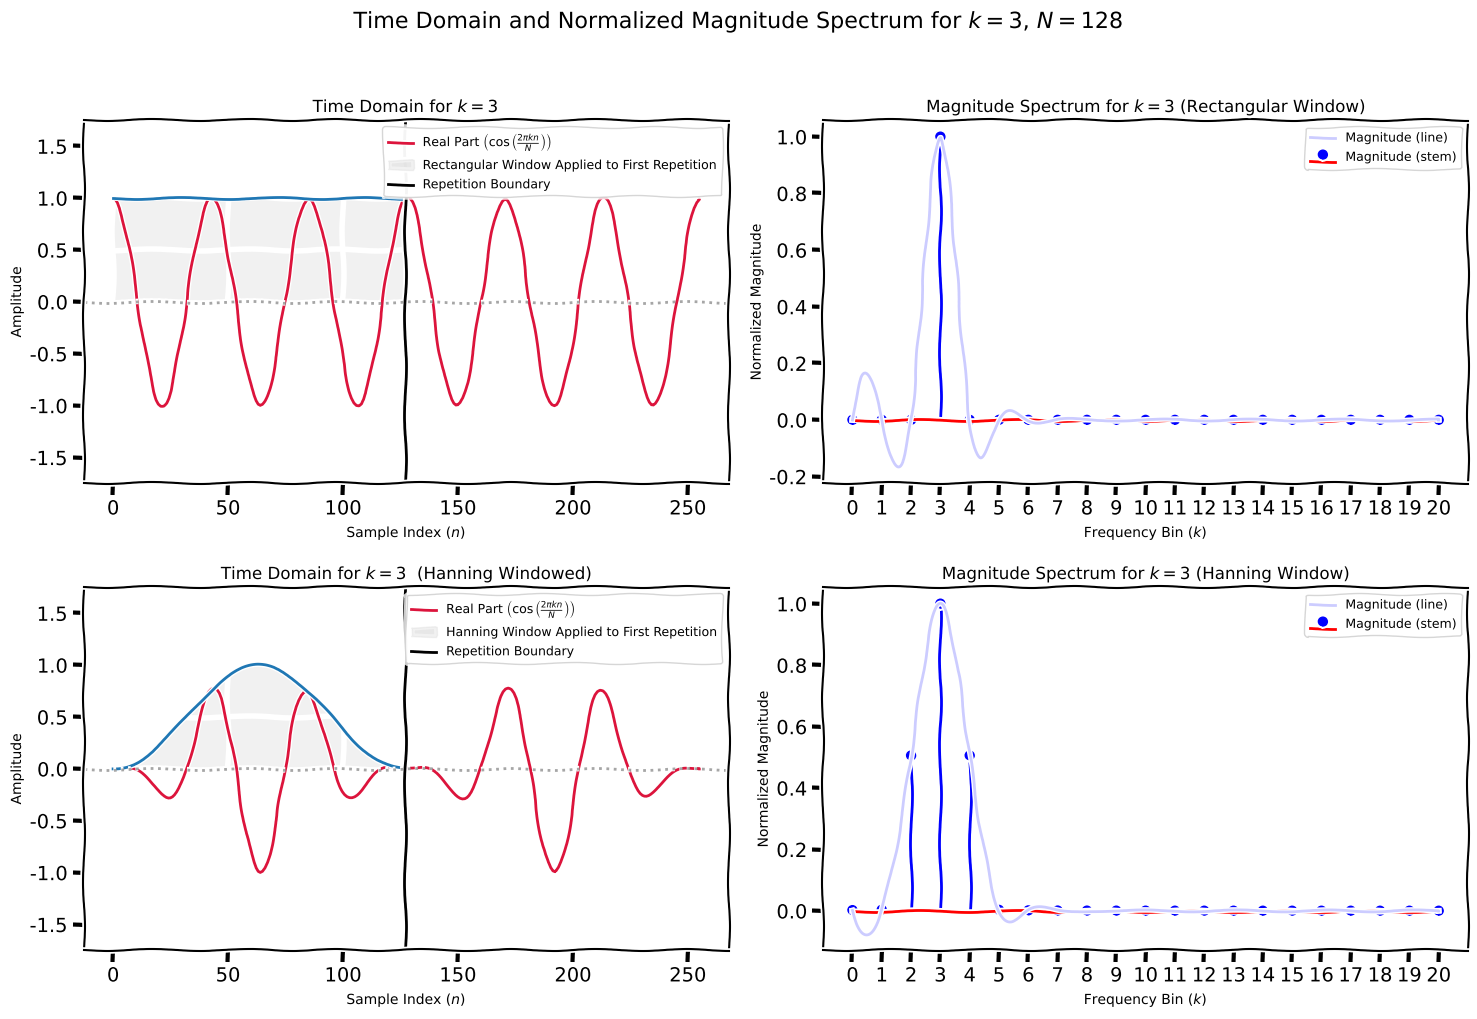

In [7]:
plot_full_analysis(k_val=3, N_samples=N)

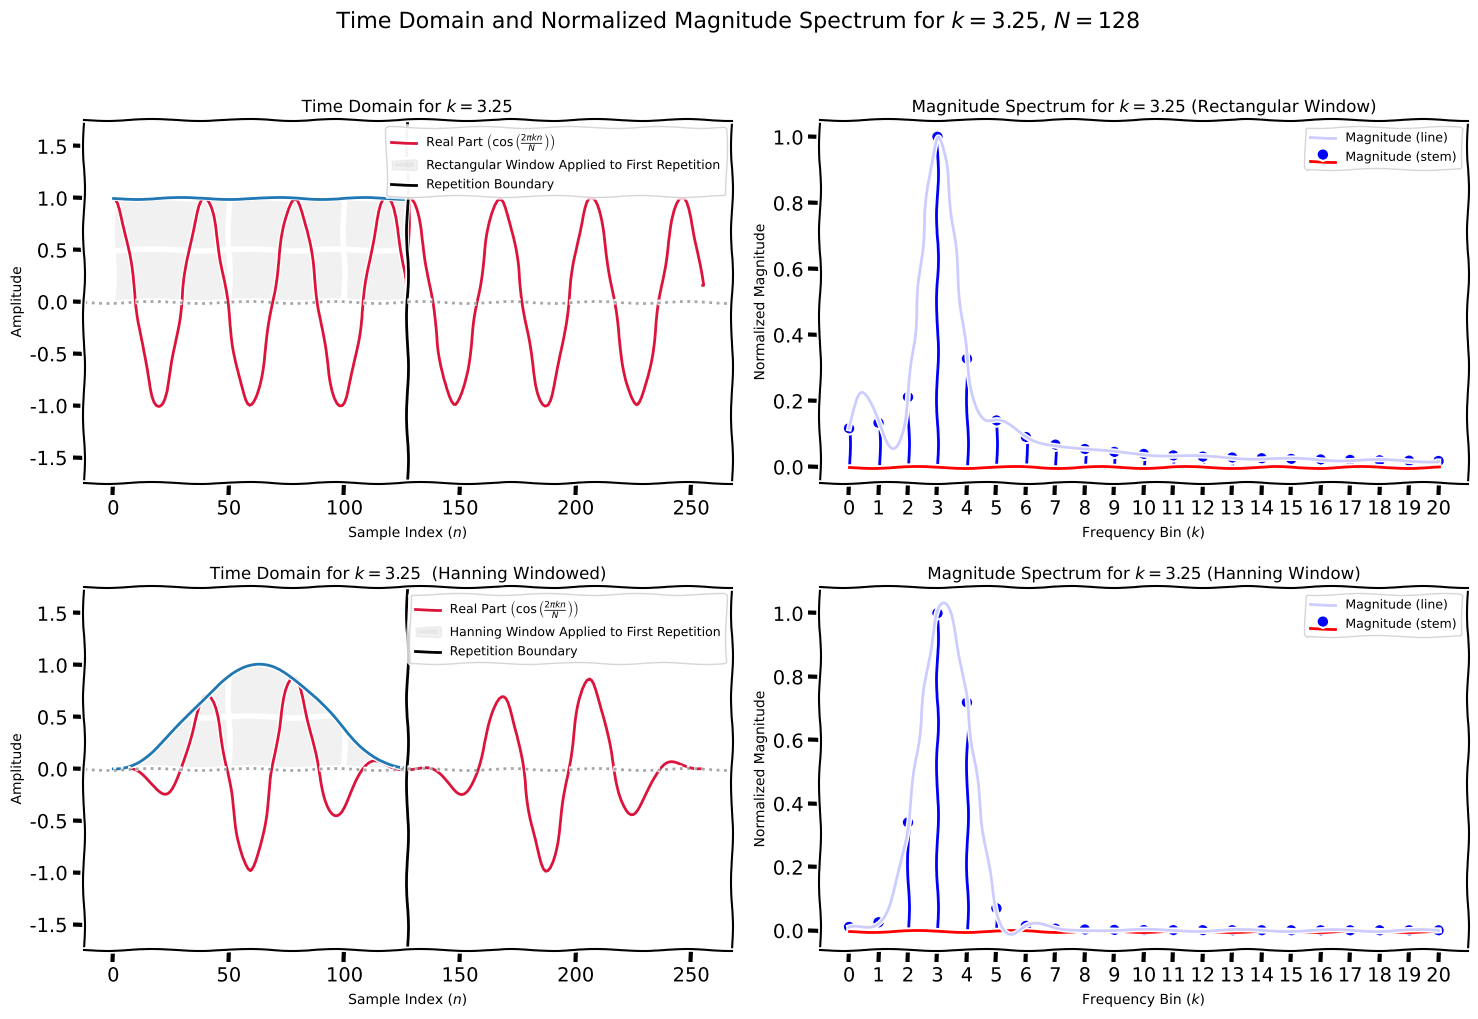

In [8]:
plot_full_analysis(k_val=3.25, N_samples=N)

# Zero-padding

Zero-padding is the process of appending zeros to a signal before performing a Discrete Fourier Transform (DFT). This does **not** add new information to the signal or improve the fundamental frequency resolution, but it interpolates the DFT in the frequency domain, resulting in a finer-grained representation of the spectrum with more samples. This can be useful for visualising the shape of the spectrum more clearly, especially when trying to identify peaks or the true underlying frequencies when they fall between DFT bins.

In the plots below we look at the magnitude spectra starting from a particular sample of the trumpet sound with different sizes of the DFT. As you can see with larger size we get more detail. Each mangitude spectrum is an array with number of samples equal to the size of the DFT. By zero padding to length 1024 all these spectra are represented by the same number of values i.e the spectrum is interpolated.

Zero-padding is frequently used in practice when we need to process segments/frames that have a length that is not a power of 2. By appending zeros we can make the array to be processed have a length that is a power of two and then apply the Fast Fourier Transform **(FFT)**.

In [32]:
audio, sr = librosa.load(librosa.ex('trumpet'))
ipd.Audio(audio, rate=sr)

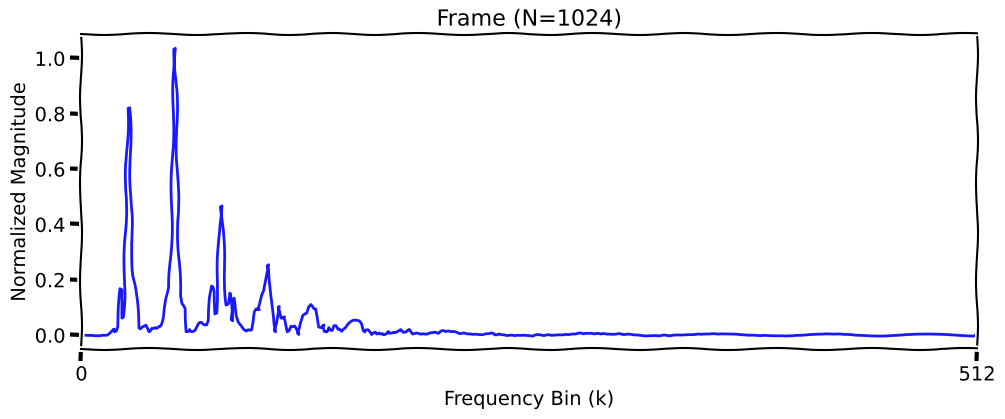

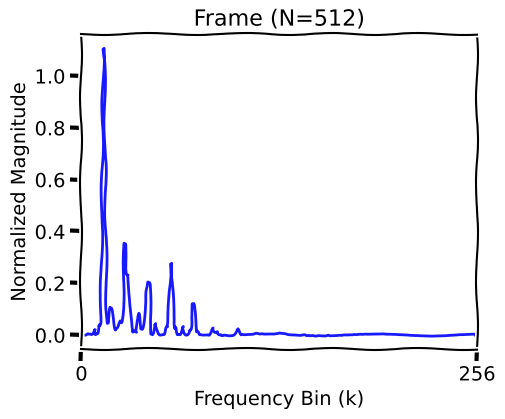

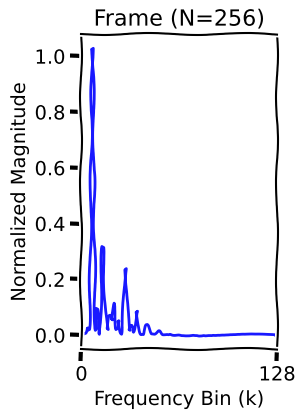

In [33]:
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt # Ensure plt is imported for standalone plots

def plot_audio_frame_magnitude_spectrum(frame, sr, ax=None):
    """
    Plots the magnitude spectrum of a given audio frame.

    Args:
        frame (np.ndarray): The audio data segment (frame) to analyze.
        sr (int): The sampling rate of the audio data.
        ax (matplotlib.axes.Axes, optional): The axes to plot on. If None, a new figure and axes will be created.
    """
    N_frame = len(frame)

    if N_frame == 0:
        print(f"Warning: Empty frame. No plot generated.")
        return

    window_frame = np.hanning(N_frame)
    windowed_frame = frame * window_frame

    dft_frame_result = np.fft.fft(windowed_frame)
    magnitude_frame_spectrum = np.abs(dft_frame_result)

    # Normalize magnitudes for better visualization
    if np.max(magnitude_frame_spectrum) > 0:
        magnitude_frame_spectrum = magnitude_frame_spectrum / np.max(magnitude_frame_spectrum)
    else:
        print(f"Warning: Magnitude spectrum is all zeros for frame of size {N_frame}. No plot generated.")
        return

    # We only care about the first half of the spectrum for real signals
    half_spectrum_length = N_frame // 2
    freq_bins = np.arange(half_spectrum_length)

    # If no axes are provided, create a new figure and axes
    if ax is None:
        # Dynamically adjust figure width based on half_spectrum_length
        fig_width = max(3, (10 / 512.0) * half_spectrum_length)
        fig, ax = plt.subplots(figsize=(fig_width, 4))
        # Only call tight_layout if it's a standalone figure
        if fig is not None:
            fig.tight_layout()

    # Interpolate for a smoother line plot
    if half_spectrum_length > 1:
        x_fine = np.linspace(0, half_spectrum_length - 1, 500)
        interp_func = interp1d(freq_bins, magnitude_frame_spectrum[:half_spectrum_length], kind='cubic', fill_value="extrapolate")
        y_fine = interp_func(x_fine)
        ax.plot(x_fine, y_fine, color='blue', alpha=0.9, linestyle='-', marker='', linewidth=2)
    else:
        # Handle cases where interpolation is not meaningful (e.g., very short frames)
        ax.plot(freq_bins, magnitude_frame_spectrum[:half_spectrum_length], color='blue', alpha=0.9, linestyle='-', marker='', label='Magnitude (line)', linewidth=2)

    ax.set_title(f'Frame (N={N_frame})', fontsize=16)
    ax.set_xlabel('Frequency Bin (k)', fontsize=14)
    ax.set_ylabel('Normalized Magnitude', fontsize=14)
    ax.grid(True, linestyle='-', alpha=0.7)
    # Only show the start and end bin on the x-axis
    ax.set_xticks([0, half_spectrum_length])
    ax.set_xlim(0, half_spectrum_length) # Explicitly set x-axis limits

# Now call the redefined function by pre-selecting the audio frames
frame = audio[4*1024 : 4*1024 + 1024]
plot_audio_frame_magnitude_spectrum(frame,sr)
frame = audio[4*1024 : 4*1024 + 512]
plot_audio_frame_magnitude_spectrum(frame,sr)
frame = audio[4*1024 : 4*1024 + 256]
plot_audio_frame_magnitude_spectrum(frame,sr)


## Zero-Padding




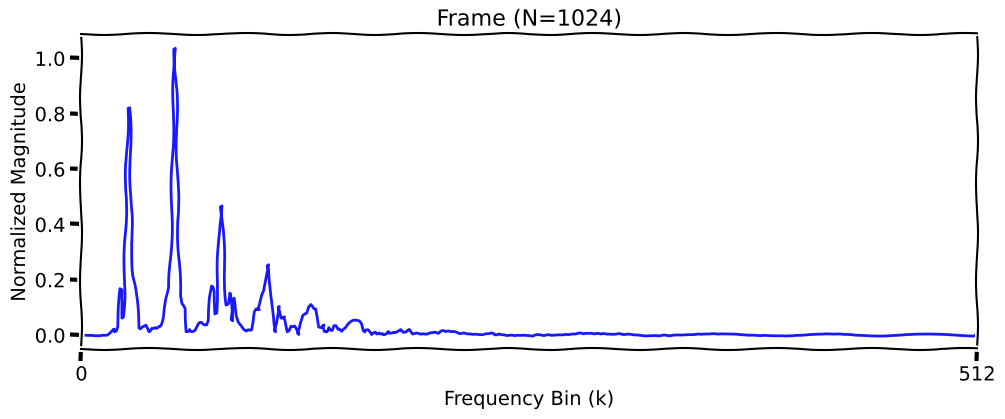

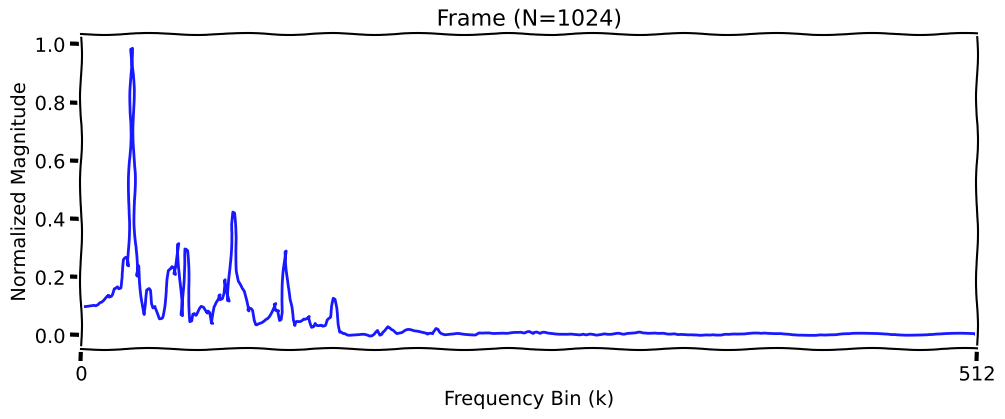

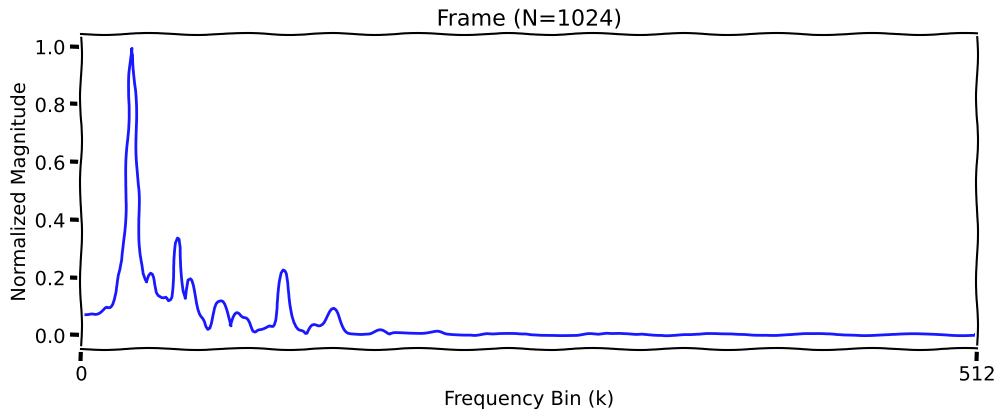

In [34]:


original_frame = audio[4*1024 : 4*1024 + 1024]
padded_frame = np.zeros(1024)
padded_frame[:1024] = original_frame
plot_audio_frame_magnitude_spectrum(padded_frame, sr)

original_frame = audio[4*1024 : 4*1024 + 512]
padded_frame = np.zeros(1024)
padded_frame[:512] = original_frame
plot_audio_frame_magnitude_spectrum(padded_frame, sr)

original_frame = audio[4*1024 : 4*1024 + 256]
padded_frame = np.zeros(1024)
padded_frame[:256] = original_frame
plot_audio_frame_magnitude_spectrum(padded_frame, sr)

# Summary

We can understand all four variants of frequency transforms (the Fourier Series, the Discrete Fourier Transform, the z-transform, and the Fourier Transform) through the lens of **Hilbert Spaces**. Essentially we form an orthogonal coordinate system by specifying a projection operation/inner product and basis elements.

**Windowing** is used to reduce **spectral leakage** that is frequencies that are not present in the signal being detected because the input contains frequencies that are not directly mapped to the DFT linear frequency grid.
By tapering at the start and the end the signal becomes periodic without discontinuities. The disadvantage is that we get side lobes.

**Zero padding** is the process of appending zeros to the end of an input signal frequently done to make it's length a power of $2$ so that the FFT algorithm can be applied. Zero padding in the time domain results in interpolation in the frequency domain.

This concludes our sound and music exposition of the Discrete Fourier Transform.